# Lab 22 — Propagation and the Link Budget: A Coverage Planner

**Companion to Chapter 11** (*The Wireless Channel*), Sections on antennas, diffraction, the two-ray model, empirical path-loss
models, atmospheric losses, link budgets and coverage. (Fading and Doppler are in Lab 5.)
**Time needed:** about 75 minutes. **Difficulty:** core.

Every radio project starts with a spreadsheet: transmit power, antenna gains, losses, the noise floor, the SNR the modem needs,
and the margin that statistics demand. The difference between what you can afford to lose and what the path takes is the
**maximum allowable path loss**, and a propagation model turns it into a cell radius and a site count. This lab builds that
spreadsheet in Python and makes every line of it interactive: antenna gain and beamwidth, Fresnel clearance and knife-edge
diffraction, the two-ray breakpoint, Hata, COST-231 and 3GPP TR 38.901 path loss with outdoor-to-indoor penetration, gas and
rain attenuation (ITU-R P.676/P.838), and the Jakes–Reudink statistics that convert shadowing into a coverage margin. It ends
with a planner that reproduces the chapter's LTE uplink budget and lets you redesign it.
Library code: `commlib/propagation.py`.

### What you will learn
1. Compute antenna gain and beamwidth, and apply Friis' equation.
2. Size Fresnel clearance on a microwave path, and compute knife-edge diffraction loss.
3. Explain the two-ray breakpoint and the $d^{-4}$ law.
4. Use Hata, COST-231 and TR 38.901 (LOS/NLOS/O2I), and know their ranges of validity.
5. Estimate gaseous and rain attenuation at millimetre-wave frequencies.
6. Turn shadowing statistics into edge and area coverage, close a link budget and find the cell radius.

### Prerequisites
Decibels and noise (Lab 1, Chapter 3). Chapter 11. Lab 5 covers fading; Lab 18 does the same job for satellite links.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Antennas and free space | yes |
| 2 | Fresnel zones and knife-edge diffraction | yes |
| 3 | The two-ray model | yes |
| 4 | Empirical models: Hata, COST-231, TR 38.901, building penetration | yes |
| 5 | Gases and rain | |
| 6 | Shadowing and coverage statistics | |
| 7 | The coverage planner | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import commlib as cl
from commlib import propagation as pr
from commlib import labkit as lk

rng = lk.setup(seed=22, lab="22")

Lab 22 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 22


## 1. Antennas and free space

An aperture antenna of area $A$ and efficiency $\eta$ has gain $G = \eta\,4\pi A/\lambda^2 = \eta(\pi D/\lambda)^2$ for a dish, and a
half-power beamwidth of roughly $70\lambda/D$ degrees. Friis' equation for free space:

$$P_r = P_t + G_t + G_r - \mathrm{FSPL},\qquad \mathrm{FSPL} = 20\log_{10}\frac{4\pi d}{\lambda}\ \text{dB}.$$

The $\lambda^2$ in FSPL is an *antenna* effect: between two fixed-*aperture* antennas, received power **grows** as $f^2$. Chapter 11's
worked example: a 60 cm dish at 12 GHz with $\eta = 0.65$ has 35.7 dBi and a 2.9° beam.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

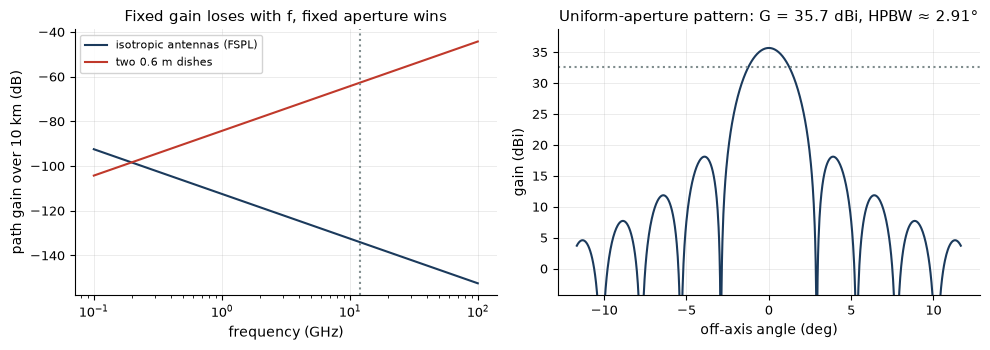

In [3]:
def antenna_demo(diam_m=0.6, f_ghz=12.0, eff=0.65):
    f = f_ghz * 1e9
    G, bw = float(pr.dish_gain_dbi(diam_m, f, eff)), float(pr.beamwidth_deg(diam_m, f))
    fr = np.logspace(8, 11, 200)
    d = 10e3
    fig, ax = lk.fig("row2", 1, 2)
    ax[0].semilogx(fr / 1e9, -pr.fspl_db(d, fr), color=lk.NAVY, label="isotropic antennas (FSPL)")
    ax[0].semilogx(fr / 1e9, -pr.fspl_db(d, fr) + 2 * pr.dish_gain_dbi(diam_m, fr, eff), color=lk.RED,
                   label=f"two {diam_m:g} m dishes")
    ax[0].axvline(f_ghz, color=lk.GRAY, ls=":")
    ax[0].set_xlabel("frequency (GHz)"); ax[0].set_ylabel("path gain over 10 km (dB)"); ax[0].legend(fontsize=8)
    ax[0].set_title("Fixed gain loses with f, fixed aperture wins")
    th = np.linspace(-4 * bw, 4 * bw, 800)
    u = np.pi * diam_m / pr.wavelength(f) * np.sin(np.deg2rad(th))
    from scipy.special import j1
    patt = np.where(np.abs(u) < 1e-9, 1.0, (2 * j1(u) / np.where(np.abs(u) < 1e-9, 1, u)) ** 2)
    ax[1].plot(th, 10 * np.log10(patt + 1e-12) + G, color=lk.NAVY)
    ax[1].axhline(G - 3, color=lk.GRAY, ls=":"); ax[1].set_ylim(G - 40, G + 3)
    ax[1].set_xlabel("off-axis angle (deg)"); ax[1].set_ylabel("gain (dBi)")
    ax[1].set_title(f"Uniform-aperture pattern: G = {G:.1f} dBi, HPBW ≈ {bw:.2f}°")
    lk.show(fig)

lk.interact(antenna_demo, diam_m=lk.slider(0.6, 0.1, 5.0, 0.05, "dish diameter (m)"), f_ghz=lk.slider(12, 0.5, 80, 0.5, "frequency (GHz)"),
            eff=lk.slider(0.65, 0.3, 0.85, 0.01, "aperture efficiency"))

**What you should see.** 35.7 dBi and about 2.9° at the defaults (the chapter's numbers). Between two dishes the path gain *improves*
by 20 dB per decade of frequency: it is why point-to-point backhaul climbs to E-band (70–80 GHz).

### Try it yourself 1.1
What gain (dBi) does a 3.7 m dish at 4 GHz (C-band earth station, $\eta = 0.65$) have?

In [5]:
answer_1_1 = None
lk.check("1.1 gain of a 3.7 m dish at 4 GHz (dBi)", answer_1_1, float(pr.dish_gain_dbi(3.7, 4e9, 0.65)), atol=0.1)

[TODO] 1.1 gain of a 3.7 m dish at 4 GHz (dBi): not attempted yet: replace the None with your answer

## 2. Fresnel zones and knife-edge diffraction

The first Fresnel zone has radius $r_1=\sqrt{\lambda d_1 d_2/(d_1+d_2)}$. An obstacle that rises a height $h$ into (or below) the line
of sight has Fresnel–Kirchhoff parameter $\nu = h\sqrt{2(d_1+d_2)/(\lambda d_1 d_2)}$ and costs $J(\nu)$ dB: 6 dB at grazing ($\nu=0$),
about 0 dB once 60% of $r_1$ is clear. The Earth bulges into the path by $d_1d_2/(2kR_e)$, with $k=4/3$ for standard refraction.

Chapter 11's worked example: 30 km at 6 GHz, $r_1 = 19.4$ m at mid-path, bulge 13.2 m; a 20 m tree line needs antennas about 45 m high.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

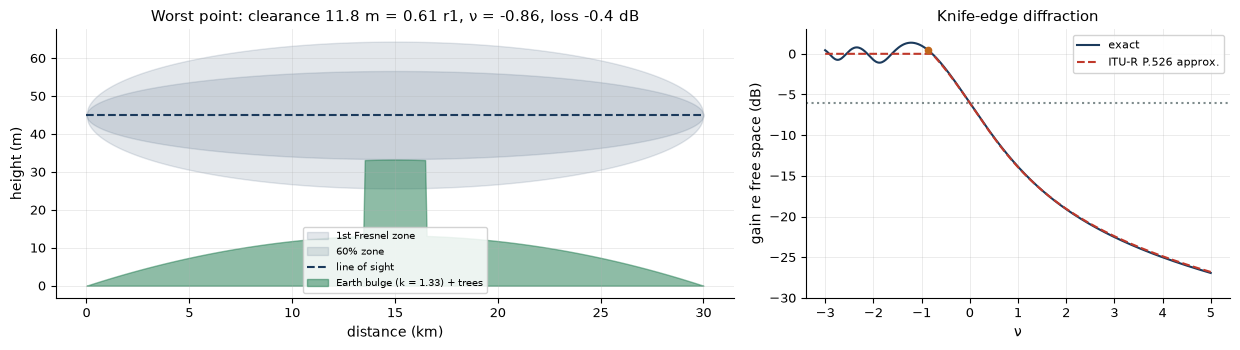

In [7]:
def clearance_demo(path_km=30.0, f_ghz=6.0, h_ant=45.0, tree_m=20.0, k_factor=4 / 3):
    D = path_km * 1e3
    x = np.linspace(0, D, 400)
    bulge = pr.earth_bulge(x, D - x, k_factor)
    r1 = pr.fresnel_radius(np.maximum(x, 1), np.maximum(D - x, 1), f_ghz * 1e9)
    los = np.full_like(x, h_ant)
    obst = bulge + np.where(np.abs(x - D / 2) < 1500, tree_m, 0)
    h = obst - los                                         # >0 = obstacle above the line of sight
    i = np.argmax(h / np.maximum(r1, 1e-9))
    v = pr.fresnel_v(h[i], x[i], D - x[i], pr.wavelength(f_ghz * 1e9))
    L = float(pr.knife_edge_loss(v))
    fig, ax = lk.fig((12.5, 3.6), 1, 2, gridspec_kw=dict(width_ratios=[1.6, 1]))
    ax[0].fill_between(x / 1e3, los - r1, los + r1, color=lk.NAVY, alpha=0.12, label="1st Fresnel zone")
    ax[0].fill_between(x / 1e3, los - 0.6 * r1, los + 0.6 * r1, color=lk.NAVY, alpha=0.12, label="60% zone")
    ax[0].plot(x / 1e3, los, "--", color=lk.NAVY, label="line of sight")
    ax[0].fill_between(x / 1e3, 0, obst, color=lk.GREEN, alpha=0.5, label=f"Earth bulge (k = {k_factor:.2f}) + trees")
    ax[0].set_xlabel("distance (km)"); ax[0].set_ylabel("height (m)"); ax[0].legend(fontsize=7.5, loc="lower center")
    ax[0].set_title(f"Worst point: clearance {-h[i]:.1f} m = {-h[i] / r1[i]:.2f} r1, ν = {v:.2f}, loss {L:.1f} dB")
    vv = np.linspace(-3, 5, 400)
    ax[1].plot(vv, -pr.knife_edge_loss(vv), color=lk.NAVY, label="exact")
    ax[1].plot(vv, -pr.knife_edge_loss_p526(vv), "--", color=lk.RED, label="ITU-R P.526 approx.")
    ax[1].plot(v, -L, "o", color=lk.ORANGE); ax[1].axhline(-6, color=lk.GRAY, ls=":")
    ax[1].set_xlabel("ν"); ax[1].set_ylabel("gain re free space (dB)"); ax[1].legend(fontsize=8); ax[1].set_ylim(-30, 3)
    ax[1].set_title("Knife-edge diffraction")
    lk.show(fig)

lk.interact(clearance_demo, path_km=lk.slider(30, 2, 60, 1, "path length (km)"), f_ghz=lk.slider(6, 1, 40, 0.5, "frequency (GHz)"),
            h_ant=lk.slider(45, 10, 100, 1, "antenna heights (m)"), tree_m=lk.slider(20, 0, 40, 1, "mid-path tree line (m)"),
            k_factor=lk.slider(4 / 3, 0.5, 3.0, 0.05, "effective Earth factor k"))

**What you should see.** With 45 m towers the worst point clears by about 0.6 $r_1$ and the diffraction loss is near 0 dB. Drop $k$ to 2/3
(sub-refraction: the bulge doubles) and the path becomes obstructed; lower the towers to 33 m and the tree line touches the ray
($\nu\approx 0$, 6 dB). Microwave planners check both conditions.

### Try it yourself 2.1
What is the knife-edge loss (dB) when an obstacle protrudes 10 m above the line of sight at the midpoint of a 10 km, 2 GHz path?

In [9]:
answer_2_1 = None
lk.check("2.1 knife-edge loss, h = 10 m, 5 km + 5 km, 2 GHz (dB)", answer_2_1,
         float(pr.knife_edge_loss(pr.fresnel_v(10, 5e3, 5e3, pr.wavelength(2e9)))), atol=0.2)

[TODO] 2.1 knife-edge loss, h = 10 m, 5 km + 5 km, 2 GHz (dB): not attempted yet: replace the None with your answer

## 3. The two-ray model

A direct ray and a ground reflection: close in they interfere constructively and destructively (deep nulls), beyond the last
maximum at $4h_th_r/\lambda$ the reflection (coefficient ≈ −1 at grazing) cancels the direct ray more and more, and beyond the
crossover $4\pi h_th_r/\lambda$ the received power falls as $d^{-4}$ and becomes *independent of frequency*:
$P_r/P_t \approx (h_th_r/d^2)^2$.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

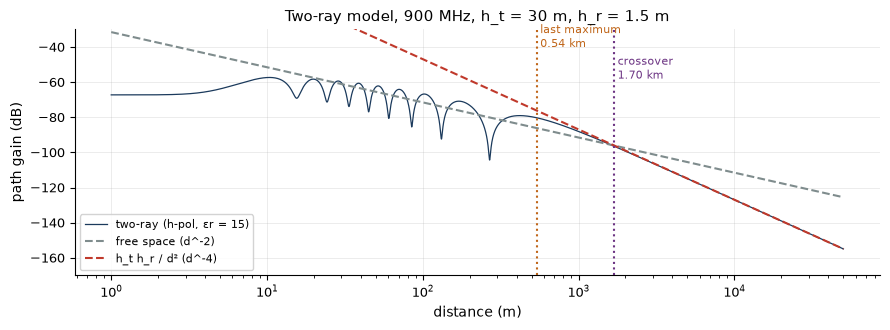

In [11]:
def two_ray_demo(f_mhz=900.0, ht=30.0, hr=1.5, pol="h"):
    f = f_mhz * 1e6
    d = np.logspace(0, 4.7, 4000)
    fig, ax = lk.fig("wide")
    ax.semilogx(d, pr.two_ray_gain_db(d, f, ht, hr, 15.0, pol), color=lk.NAVY, lw=0.9, label=f"two-ray ({pol}-pol, εr = 15)")
    ax.semilogx(d, -pr.fspl_db(d, f), "--", color=lk.GRAY, label="free space (d^-2)")
    ax.semilogx(d, 20 * np.log10(ht * hr / d ** 2), "--", color=lk.RED, label="h_t h_r / d² (d^-4)")
    lam = pr.wavelength(f)
    for xv, lab, col, yt in [(4 * ht * hr / lam, "last maximum", lk.ORANGE, -40), (4 * np.pi * ht * hr / lam, "crossover", lk.PURPLE, -58)]:
        ax.axvline(xv, color=col, ls=":"); ax.text(xv * 1.05, yt,f"{lab}\n{xv / 1e3:.2f} km", color=col, fontsize=8)
    ax.set_ylim(-170, -30); ax.set_xlabel("distance (m)"); ax.set_ylabel("path gain (dB)"); ax.legend(fontsize=8, loc="lower left")
    ax.set_title(f"Two-ray model, {f_mhz:g} MHz, h_t = {ht:g} m, h_r = {hr:g} m")
    lk.show(fig)

lk.interact(two_ray_demo, f_mhz=lk.slider(900, 100, 6000, 50, "frequency (MHz)"), ht=lk.slider(30, 2, 100, 1, "TX height (m)"),
            hr=lk.slider(1.5, 0.5, 20, 0.1, "RX height (m)"), pol=lk.choice(["h", "v"], "h", "polarisation"))

**What you should see.** For 900 MHz, 30 m and 1.5 m, the crossover is near 1.7 km; beyond it the curve hugs the $d^{-4}$ asymptote.
Raising the base station pushes the breakpoint out (and is the single cheapest way to increase range). Vertical polarisation shows
the Brewster-angle effect: the reflection weakens at intermediate distances.

## 4. Empirical models: Hata, COST-231, TR 38.901, building penetration

Real cities are fitted, not solved. Okumura–Hata (150–1500 MHz, 1–20 km, base 30–200 m) and its COST-231 extension (1.5–2 GHz) are the
classical macro-cell models; 3GPP TR 38.901 covers 0.5–100 GHz for urban macro (UMa), urban micro (UMi) and indoor hotspot (InH), with
separate LOS and NLOS laws, a breakpoint, shadowing standard deviations, and outdoor-to-indoor (O2I) penetration.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

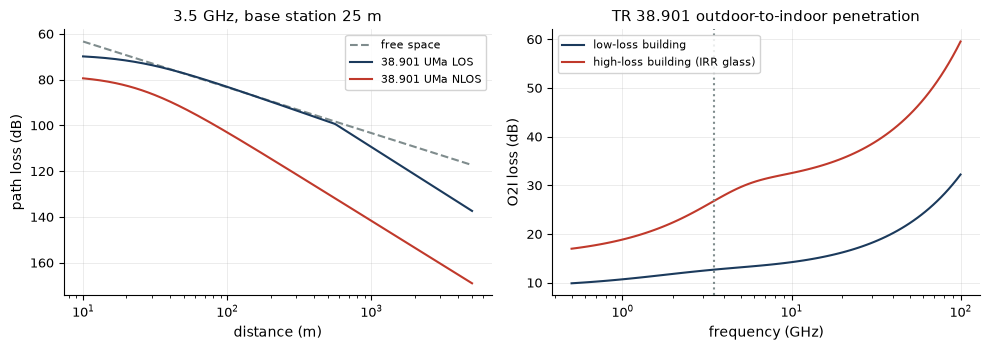

f (GHz),low-loss (dB),high-loss (dB)
0.9,10.6,18.5
3.5,12.7,26.8
28,17.8,37.9


In [13]:
def models_demo(f_ghz=3.5, h_bs=25.0, scenario="UMa"):
    d = np.logspace(1, np.log10(5000), 300)
    fig, ax = lk.fig("row2", 1, 2)
    los, nlos = pr.pl_38901(scenario, d, f_ghz, h_bs)
    ax[0].semilogx(d, pr.fspl_db(d, f_ghz * 1e9), color=lk.GRAY, ls="--", label="free space")
    ax[0].semilogx(d, los, color=lk.NAVY, label=f"38.901 {scenario} LOS")
    ax[0].semilogx(d, nlos, color=lk.RED, label=f"38.901 {scenario} NLOS")
    if 0.15 <= f_ghz <= 2.0 and h_bs >= 30:
        dk = d[d >= 1000] / 1e3
        fm = f_ghz * 1e3
        ax[0].semilogx(d[d >= 1000], pr.hata(fm, h_bs, 1.5, dk) if fm <= 1500 else pr.cost231(fm, h_bs, 1.5, dk, 0), color=lk.GREEN,
                       label="Hata / COST-231 (≥ 1 km)")
    ax[0].set_xlabel("distance (m)"); ax[0].set_ylabel("path loss (dB)"); ax[0].legend(fontsize=8); ax[0].invert_yaxis()
    ax[0].set_title(f"{f_ghz:g} GHz, base station {h_bs:g} m")
    fg = np.logspace(np.log10(0.5), 2, 100)
    ax[1].semilogx(fg, pr.o2i_loss_db(fg, "low"), color=lk.NAVY, label="low-loss building")
    ax[1].semilogx(fg, pr.o2i_loss_db(fg, "high"), color=lk.RED, label="high-loss building (IRR glass)")
    ax[1].axvline(f_ghz, color=lk.GRAY, ls=":"); ax[1].set_xlabel("frequency (GHz)"); ax[1].set_ylabel("O2I loss (dB)")
    ax[1].legend(fontsize=8); ax[1].set_title("TR 38.901 outdoor-to-indoor penetration")
    lk.show(fig)

lk.interact(models_demo, f_ghz=lk.slider(3.5, 0.5, 40, 0.1, "frequency (GHz)"), h_bs=lk.slider(25, 10, 60, 1, "BS height (m)"),
            scenario=lk.choice(["UMa", "UMi", "InH"], "UMa", "scenario"))
lk.table([[f, float(pr.o2i_loss_db(f, "low")), float(pr.o2i_loss_db(f, "high"))] for f in (0.9, 3.5, 28)],
         ["f (GHz)", "low-loss (dB)", "high-loss (dB)"], fmt=".1f", title="O2I penetration (the TR 38.901 table of Chapter 11)")

**What you should see.** UMa NLOS at 3.5 GHz falls roughly 39 dB per decade of distance (an exponent near 3.9), LOS near 22 dB per decade
until the breakpoint. At 1.8 GHz with a 30 m mast, the COST-231 curve lies close to the 38.901 NLOS curve. The O2I table matches the
chapter (10.6/12.7/17.8 dB for low-loss, 18.5/26.8/37.9 dB for high-loss buildings): at 28 GHz metallised glass is nearly a Faraday cage.

## 5. Gases and rain

Above about 10 GHz the atmosphere joins the budget. Oxygen absorbs strongly around 60 GHz (about 15 dB/km at sea level) and water vapour
at 22 and 183 GHz. Rain attenuates by $\gamma_R = kR^\alpha$ dB/km (ITU-R P.838). Chapter 11's worked example: at 20 GHz, $R = 50$ mm/h,
$k = 0.092$, $\alpha = 1.057$, $\gamma_R \approx 5.7$ dB/km; over an effective 3 km, about 17 dB.

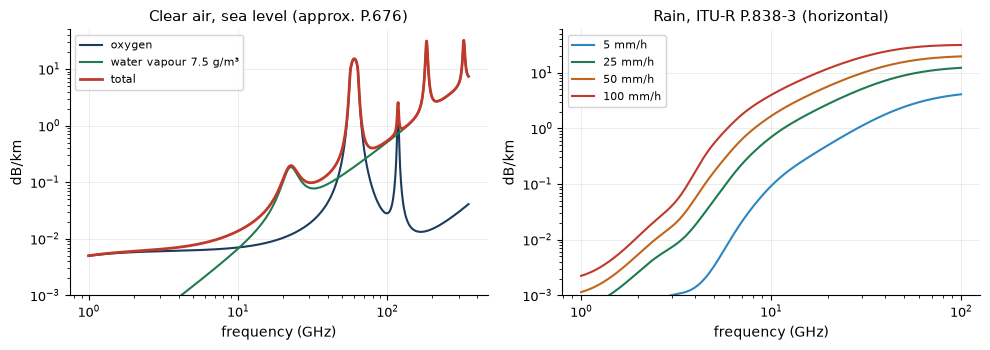

,value
"k, alpha at 20 GHz","0.0916, 1.057"
"gamma_R at 50 mm/h, 20 GHz (dB/km)",5.72
fade over 3 km effective path (dB),17.2
same storm at 12 GHz (dB),7.3
60 GHz oxygen over 500 m (dB),7.6


In [15]:
f = np.logspace(0, np.log10(350), 800)
go, gw = pr.gas_atten(f)
fr = np.logspace(0, 2, 300)
fig, ax = lk.fig("row2", 1, 2)
ax[0].loglog(f, go, color=lk.NAVY, label="oxygen"); ax[0].loglog(f, gw, color=lk.GREEN, label="water vapour 7.5 g/m³")
ax[0].loglog(f, go + gw, color=lk.RED, lw=2, label="total"); ax[0].set_ylim(1e-3, 50)
ax[0].set_xlabel("frequency (GHz)"); ax[0].set_ylabel("dB/km"); ax[0].legend(fontsize=8); ax[0].set_title("Clear air, sea level (approx. P.676)")
for R, col in [(5, lk.BLUE), (25, lk.GREEN), (50, lk.ORANGE), (100, lk.RED)]:
    ax[1].loglog(fr, pr.rain_specific_atten(fr, R), color=col, label=f"{R} mm/h")
ax[1].set_ylim(1e-3, 60); ax[1].set_xlabel("frequency (GHz)"); ax[1].set_ylabel("dB/km"); ax[1].legend(fontsize=8)
ax[1].set_title("Rain, ITU-R P.838-3 (horizontal)")
lk.show(fig)
k20, a20 = pr.rain_k_alpha(20.0)
lk.table([["k, alpha at 20 GHz", f"{float(k20):.4f}, {float(a20):.3f}"],
          ["gamma_R at 50 mm/h, 20 GHz (dB/km)", f"{float(pr.rain_specific_atten(20, 50)):.2f}"],
          ["fade over 3 km effective path (dB)", f"{3 * float(pr.rain_specific_atten(20, 50)):.1f}"],
          ["same storm at 12 GHz (dB)", f"{3 * float(pr.rain_specific_atten(12, 50)):.1f}"],
          ["60 GHz oxygen over 500 m (dB)", f"{0.5 * float((go + gw)[np.argmin(abs(f - 60))]):.1f}"]], ["", "value"])

**What you should see.** The chapter's 5.7 dB/km and about 17 dB for the 20 GHz storm; the same storm at 12 GHz costs about 7 dB. At 60 GHz,
500 m of air alone takes roughly 7–8 dB: a nuisance for range, a gift for frequency reuse (WiGig, 802.11ad/ay).

### Try it yourself 5.1
What is the specific rain attenuation (dB/km) at 38 GHz for a 25 mm/h downpour?

In [17]:
answer_5_1 = None
lk.check("5.1 rain attenuation at 38 GHz, 25 mm/h (dB/km)", answer_5_1, float(pr.rain_specific_atten(38, 25)), rtol=0.03)

[TODO] 5.1 rain attenuation at 38 GHz, 25 mm/h (dB/km): not attempted yet: replace the None with your answer

## 6. Shadowing and coverage statistics

Shadowing makes the local mean path loss log-normal with standard deviation $\sigma$ (6–10 dB outdoors). A margin $M$ covers the cell
**edge** with probability $\Phi(M/\sigma)$; because users inside the cell enjoy more signal, the **area** coverage is higher
(Jakes–Reudink, eq. 11.areacov). The chapter's numbers: $n = 3.5$, $\sigma = 8$ dB, 95% area coverage needs 86% edge coverage, an 8.7 dB margin.
Below we check the formula by Monte Carlo: users dropped uniformly in a circular cell, log-distance path loss plus shadowing.

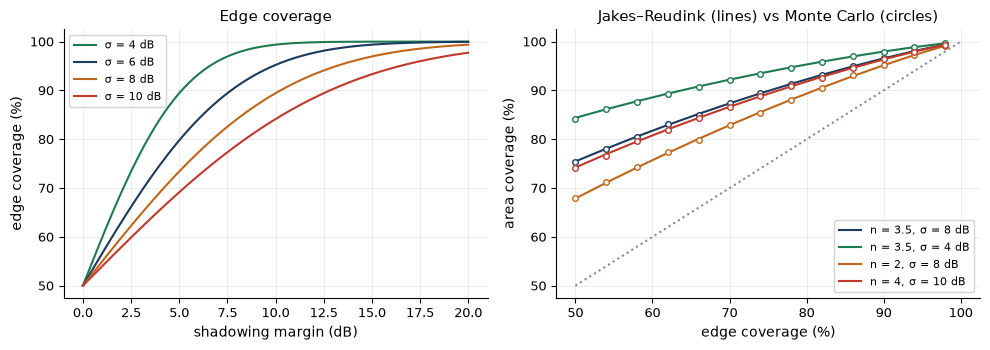

"n = 3.5, σ = 8 dB",
edge coverage needed for 95% area,86.2%
shadowing margin,8.70 dB
area covered with 75% at the edge,89.9%


In [19]:
def mc_area(p_edge, n, sigma, N=200_000):
    r = np.sqrt(rng.random(N))                                # uniform over a unit-radius disc
    margin = norm.ppf(p_edge) * sigma
    excess = margin - 10 * n * np.log10(np.maximum(r, 1e-6))   # median dB above threshold at radius r
    return np.mean(excess + sigma * rng.standard_normal(N) > 0)

pe = np.linspace(0.5, 0.98, 13)
fig, ax = lk.fig("row2", 1, 2)
for n, s, col in [(3.5, 8, lk.NAVY), (3.5, 4, lk.GREEN), (2.0, 8, lk.ORANGE), (4.0, 10, lk.RED)]:
    ax[1].plot(100 * pe, 100 * pr.area_coverage(pe, n, s), color=col, label=f"n = {n:g}, σ = {s} dB")
    ax[1].plot(100 * pe, [100 * mc_area(p, n, s, 40_000) for p in pe], "o", color=col, mfc="white", ms=4)
ax[1].plot([50, 100], [50, 100], ":", color=lk.GRAY)
ax[1].set_xlabel("edge coverage (%)"); ax[1].set_ylabel("area coverage (%)"); ax[1].legend(fontsize=8)
ax[1].set_title("Jakes–Reudink (lines) vs Monte Carlo (circles)")
M = np.linspace(0, 20, 200)
for s, col in [(4, lk.GREEN), (6, lk.NAVY), (8, lk.ORANGE), (10, lk.RED)]:
    ax[0].plot(M, 100 * pr.edge_coverage(M, s), color=col, label=f"σ = {s} dB")
ax[0].set_xlabel("shadowing margin (dB)"); ax[0].set_ylabel("edge coverage (%)"); ax[0].legend(fontsize=8); ax[0].set_title("Edge coverage")
lk.show(fig)
m95, pe95 = pr.edge_margin_for_area(0.95, 3.5, 8)
lk.table([["edge coverage needed for 95% area", f"{100 * pe95:.1f}%"], ["shadowing margin", f"{m95:.2f} dB"],
          ["area covered with 75% at the edge", f"{100 * float(pr.area_coverage(0.75, 3.5, 8)):.1f}%"]], ["n = 3.5, σ = 8 dB", ""])

**What you should see.** The Monte Carlo circles sit on the curves, and the table reproduces the chapter: 86% edge, 8.7 dB margin, and 90%
area coverage for 75% at the edge.

## 7. The coverage planner

The LTE uplink budget table of Chapter 11: 23 dBm UE, 3 dB body loss, 360 kHz (two resource blocks), 2 dB NF, −4 dB required SINR,
18 dBi sector antenna, 2 dB feeder, 2 dB interference margin, shadowing margin for 95% area coverage, 15 dB penetration: MAPL 130.7 dB,
radius 0.70 km with COST-231 (medium city), 1.9 km without the building loss. Change anything.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

item,dB / dBm
UE EIRP (23 dBm - 3 dB body),20.00
thermal noise + NF,-116.41
required SINR,-4.00
sensitivity,-120.41
BS antenna gain,18.00
feeder loss,-2.00
interference margin,-2.00
"shadowing margin (95% area, 86% edge, n = 3.52)",-8.68
building penetration,-15.00
= MAPL (dB),130.73


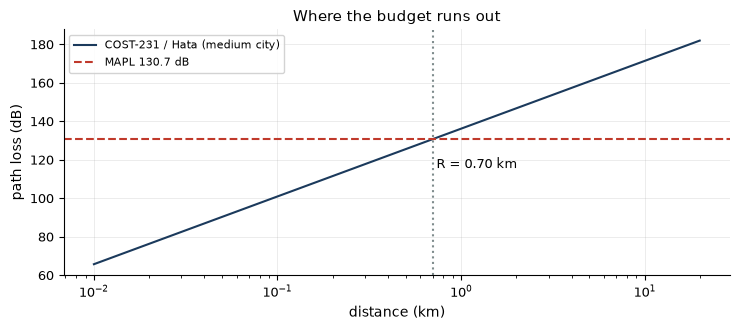

In [21]:
def planner(f_mhz=1800.0, p_ue_dbm=23.0, bw_khz=360.0, nf_db=2.0, sinr_db=-4.0, g_bs_dbi=18.0, penetration_db=15.0,
            area_target=0.95, sigma_db=8.0, model="COST-231 / Hata (medium city)", h_bs=30.0):
    eirp = p_ue_dbm - 3.0
    noise = float(pr.thermal_noise_dbm(bw_khz * 1e3, nf_db))
    sens = noise + sinr_db
    n_exp = (44.9 - 6.55 * np.log10(h_bs)) / 10 if "Hata" in model else 3.908
    margin, pedge = pr.edge_margin_for_area(area_target, n_exp, sigma_db)
    mapl = eirp - sens + g_bs_dbi - 2.0 - 2.0 - margin - penetration_db
    if "Hata" in model:
        L = (lambda d: pr.hata(f_mhz, h_bs, 1.5, d) if f_mhz <= 1500 else pr.cost231(f_mhz, h_bs, 1.5, d, 0))
    else:
        L = lambda d: float(pr.pl_38901("UMa", d * 1e3, f_mhz / 1e3, h_bs)[1])
    R = pr.radius_for_mapl(mapl, L, 0.01, 200.0)
    rows = [["UE EIRP (23 dBm - 3 dB body)", eirp], ["thermal noise + NF", noise], ["required SINR", sinr_db], ["sensitivity", sens],
            ["BS antenna gain", g_bs_dbi], ["feeder loss", -2.0], ["interference margin", -2.0],
            [f"shadowing margin ({100 * area_target:.0f}% area, {100 * pedge:.0f}% edge, n = {n_exp:.2f})", -margin],
            ["building penetration", -penetration_db], ["= MAPL (dB)", mapl], ["cell radius (km)", R],
            ["sites per 100 km² (one hexagon of radius R each)", 100 / (2.598 * R ** 2)]]
    lk.table(rows, ["item", "dB / dBm"], fmt=".2f", title=f"Uplink budget at {f_mhz:g} MHz, model: {model}")
    d = np.logspace(-2, 1.3, 200)
    fig, ax = lk.fig((7.5, 3.4))
    ax.semilogx(d, [L(x) for x in d], color=lk.NAVY, label=model)
    ax.axhline(mapl, color=lk.RED, ls="--", label=f"MAPL {mapl:.1f} dB")
    ax.axvline(R, color=lk.GRAY, ls=":"); ax.text(R * 1.05, mapl - 15, f"R = {R:.2f} km", fontsize=9)
    ax.set_xlabel("distance (km)"); ax.set_ylabel("path loss (dB)"); ax.legend(fontsize=8); ax.set_title("Where the budget runs out")
    lk.show(fig)

lk.interact(planner, f_mhz=lk.slider(1800, 700, 3800, 50, "frequency (MHz)"), p_ue_dbm=lk.slider(23, 10, 31, 0.5, "UE power (dBm)"),
            bw_khz=lk.slider(360, 180, 20000, 180, "bandwidth (kHz)"), nf_db=lk.slider(2, 0.5, 8, 0.1, "BS NF (dB)"),
            sinr_db=lk.slider(-4, -10, 20, 0.5, "required SINR (dB)"), g_bs_dbi=lk.slider(18, 0, 25, 0.5, "BS antenna gain (dBi)"),
            penetration_db=lk.slider(15, 0, 30, 0.5, "penetration (dB)"), area_target=lk.slider(0.95, 0.5, 0.99, 0.01, "area coverage"),
            sigma_db=lk.slider(8, 2, 12, 0.5, "shadowing σ (dB)"),
            model=lk.choice(["COST-231 / Hata (medium city)", "TR 38.901 UMa NLOS"], "COST-231 / Hata (medium city)", "model"),
            h_bs=lk.slider(30, 10, 60, 1, "BS height (m)"))

**What you should see.** At the defaults the planner reproduces the chapter: MAPL 130.7 dB and a 0.70 km radius (the shadowing margin
uses the Hata slope, 3.52, so it is 8.7 dB). Set penetration to 0: 1.9 km and seven times fewer sites. Move to 3500 MHz with the 38.901
model and the radius collapses, which is why mid-band 5G arrives with 32- and 64-element arrays (Chapter 19): beamforming gain is
the only knob big enough.

### Try it yourself 7.1
Using the planner (or `pr.radius_for_mapl`), what is the COST-231 cell radius (km) for a MAPL of 140 dB at 1800 MHz, $h_b = 30$ m, medium
city ($C_m = 0$)?

In [23]:
answer_7_1 = None
lk.check("7.1 COST-231 radius for MAPL 140 dB (km)", answer_7_1,
         pr.radius_for_mapl(140, lambda d: pr.cost231(1800, 30, 1.5, d, 0)), rtol=0.02)

[TODO] 7.1 COST-231 radius for MAPL 140 dB (km): not attempted yet: replace the None with your answer

## Key takeaways
* Gain needs aperture: between fixed apertures, higher frequency helps; between fixed-gain antennas it hurts.
* Keep 60% of the first Fresnel zone clear for the worst-case $k$; grazing costs 6 dB.
* Beyond the two-ray breakpoint power falls as $d^{-4}$; mast height buys range.
* Use empirical models inside their validity ranges; TR 38.901 is the 5G reference, with O2I loss often the biggest single term.
* Above 10 GHz, rain (P.838/P.618) and gases (P.676) are budget lines; at 60 GHz oxygen dominates.
* Shadowing sets the margin: area coverage exceeds edge coverage (95% area ≈ 86% edge for n = 3.5, σ = 8 dB).

## Going further (hardware: USRP B200 / GNU Radio)
* Measure path loss: transmit a CW tone at 915 MHz (or 433/868 MHz in Region 1) from one B200 at a fixed low power and record the received
  power with `gr01_spectrum_iq_capture.py` on a laptop as you walk away. Fit a log-distance exponent and a shadowing σ to your data.
* Use `gr03_channel_sounder.py` indoors and outdoors and compare the RMS delay spread with `pr.rms_delay_spread` on the TR 38.901 profiles.

## Exercises
1. **(Warm-up)** Reproduce the sensitivity of −120.4 dBm in the LTE budget from kTB, NF and SINR.
2. **(Core)** For a 28 GHz UMi small cell (10 m mast, 400 MHz, 30 dBm EIRP per beam, 64-element array at the base), compute the downlink
   MAPL and radius for outdoor and for high-loss-building users.
3. **(Core)** Add foliage (1–2 dB/m at millimetre wave) and body blockage (15–25 dB) to the planner and report the radius.
4. **(Stretch)** Generate a spatially correlated shadowing map (exponential correlation, 50 m) on a 2 km × 2 km grid with three base
   stations and compute the coverage map and the best-server map.

In [25]:
lk.summary()

[good] Lab 22 finished in 2.2 s. Self-checks: 0 passed, 0 failed, 4 still to do.